<a href="https://colab.research.google.com/github/Vagiadim/SiteAI-equipment-tracker-/blob/main/notebooks/github_B01_M04_U03_COLABDRAFT_VD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Environment Setup
This cell installs the necessary library and checks if your GPU is active.

Note: Make sure you went to Edit > Notebook settings and selected T4 GPU

In [ ]:
# Install Ultralytics (YOLOv8)
%pip install ultralytics==8.3.0 --quiet

import ultralytics
from ultralytics import YOLO
import torch
import os
import glob
import yaml
from IPython.display import display, Image

# Verify environment
ultralytics.checks()
print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Ultralytics version: {ultralytics.__version__}")
print("\n✅ Environment ready.")

Ultralytics 8.3.0 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 42.0/235.7 GB disk)

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Ultralytics version: 8.3.0

✅ Environment ready.


# Dataset Download (automated, no manual upload)

In [1]:
# ============================================================
# Option B: Download dataset zip from GitHub Release
# ============================================================
import zipfile

# Download from your GitHub release
!wget -q -O dataset.zip "https://github.com/Vagiadim/SiteAI-equipment-tracker-/releases/download/v1.0/dataset.zip"

# Extract
with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("\n✅ Dataset downloaded from GitHub and extracted.")

BadZipFile: File is not a zip file

# Fix Dataset Paths (YAML)
Roboflow gives us a data.yaml file, but it doesn't know we are on Google Colab. We need to tell it exactly where the images are.

In [ ]:
import yaml

yaml_path = '/content/dataset/data.yaml'

with open(yaml_path, 'r') as f:
    config = yaml.safe_load(f)

# Update paths for Colab
config['train'] = '/content/dataset/train/images'
config['val']   = '/content/dataset/valid/images'
config['test']  = '/content/dataset/test/images'

with open(yaml_path, 'w') as f:
    yaml.dump(config, f)

# Display the config
print("Dataset configuration:")
print(f"  Train: {config['train']}")
print(f"  Val:   {config['val']}")
print(f"  Test:  {config['test']}")
print(f"  Classes ({config['nc']}): {config['names']}")

# Count images per split
for split in ['train', 'val', 'test']:
    path = config.get(split, '')
    if os.path.exists(path):
        count = len([f for f in os.listdir(path) if f.endswith(('.jpg','.jpeg','.png'))])
        print(f"  {split}: {count} images")

print("\n✅ Paths configured.")

Dataset configuration:
  Train: /content/dataset/train/images
  Val:   /content/dataset/valid/images
  Test:  /content/dataset/test/images
  Classes (7): ['boom_lift', 'dump_truck', 'excavator', 'loader', 'mixer_truck', 'roller', 'tower_crane']
  train: 1391 images
  val: 59 images
  test: 58 images

✅ Paths configured.


# Train YOLOv8n
Now we train. This uses the Nano model and RAM caching for speed.

In [ ]:
from ultralytics import YOLO

# Load pre-trained YOLOv8 Nano
model = YOLO('yolov8n.pt')

# Train
results = model.train(
    data='/content/dataset/data.yaml',
    epochs=30,
    imgsz=640,
    batch=-1,       # Auto batch size
    cache=True,     # Cache images in RAM for speed
    name='siteai_equipment',
    patience=10,    # Early stopping if no improvement for 10 epochs
    save=True,      # Save checkpoints
    plots=True      # Generate training plots
)

print("\n✅ Training complete!")

100%|██████████| 6.25M/6.25M [00:00<00:00, 249MB/s]

New https://pypi.org/project/ultralytics/8.4.15 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.0 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)


engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/dataset/data.yaml, epochs=30, time=None, patience=10, batch=-1, imgsz=640, save=True, save_period=-1, cache=True, device=None, workers=8, project=None, name=siteai_equipment, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_width=None, format=torchscript, keras=False, optimize=False, 

100%|██████████| 755k/755k [00:00<00:00, 148MB/s]


Overriding model.yaml nc=80 with nc=7

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

...

      30/30      9.94G     0.7895     0.7973      1.093          8        640: 100%|██████████| 22/22 [00:17<00:00,  1.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  1.04it/s]

                   all         59        184      0.827       0.53      0.661      0.511



30 epochs completed in 0.182 hours.
Optimizer stripped from runs/detect/siteai_equipment/weights/last.pt, 5.6MB
Optimizer stripped from runs/detect/siteai_equipment/weights/best.pt, 5.6MB

Validating runs/detect/siteai_equipment/weights/best.pt...
Ultralytics 8.3.0 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 186 layers, 2,685,733 parameters, 0 gradients, 6.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  2.37it/s]


                   all         59        184      0.826       0.53      0.661      0.512
             boom_lift          2          5      0.696        0.4      0.496      0.357
            dump_truck         11         49      0.806       0.17      0.377      0.215
             excavator         16         52      0.807      0.563      0.692      0.461
                loader          4          6       0.94      0.833      0.955        0.8
           mixer_truck         10         23      0.975      0.783      0.879      0.761
                roller         10         13      0.928      0.769      0.913      0.808
           tower_crane          9         36      0.633      0.192      0.319      0.181
Speed: 0.2ms preprocess, 2.4ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/siteai_equipment

✅ Training complete!


# Evaluate Model & Print Metrics

In [ ]:
from ultralytics import YOLO

# Load the best weights from training
best_weights = '/content/runs/detect/siteai_equipment/weights/best.pt'
model = YOLO(best_weights)

# Run validation
metrics = model.val(data='/content/dataset/data.yaml')

# Print results summary
print("\n" + "="*50)
print("         MODEL EVALUATION RESULTS")
print("="*50)
print(f"  Precision:    {metrics.box.mp:.3f}")
print(f"  Recall:       {metrics.box.mr:.3f}")
print(f"  mAP@50:       {metrics.box.map50:.3f}")
print(f"  mAP@50-95:    {metrics.box.map:.3f}")
print("="*50)

# Per-class results
print("\nPer-class mAP@50:")
class_names = model.names
for i, ap in enumerate(metrics.box.ap50):
    name = class_names[i] if i in class_names else f"class_{i}"
    bar = '█' * int(ap * 30)
    print(f"  {name:<15} {ap:.1%}  {bar}")

print("\n✅ Evaluation complete.")

Ultralytics 8.3.0 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 186 layers, 2,685,733 parameters, 0 gradients, 6.8 GFLOPs


val: Scanning /content/dataset/valid/labels.cache... 59 images, 7 backgrounds, 0 corrupt: 100%|██████████| 59/59 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:02<00:00,  1.66it/s]


                   all         59        184      0.828      0.529      0.661      0.513
             boom_lift          2          5      0.703        0.4      0.496      0.357
            dump_truck         11         49      0.804      0.168      0.379      0.221
             excavator         16         52      0.806      0.561      0.692      0.457
                loader          4          6      0.943      0.833      0.955        0.8
           mixer_truck         10         23      0.977      0.783      0.879      0.762
                roller         10         13      0.932      0.769      0.913      0.809
           tower_crane          9         36      0.627      0.188      0.316      0.181
Speed: 0.9ms preprocess, 9.6ms inference, 0.0ms loss, 5.1ms postprocess per image
Results saved to runs/detect/val

         MODEL EVALUATION RESULTS
  Precision:    0.828
  Recall:       0.529
  mAP@50:       0.661
  mAP@50-95:    0.513

Per-class mAP@50:
  boom_lift       49.6%  ██████

# Display Training Curves

📊 Training Curves & Plots

--- results.png ---


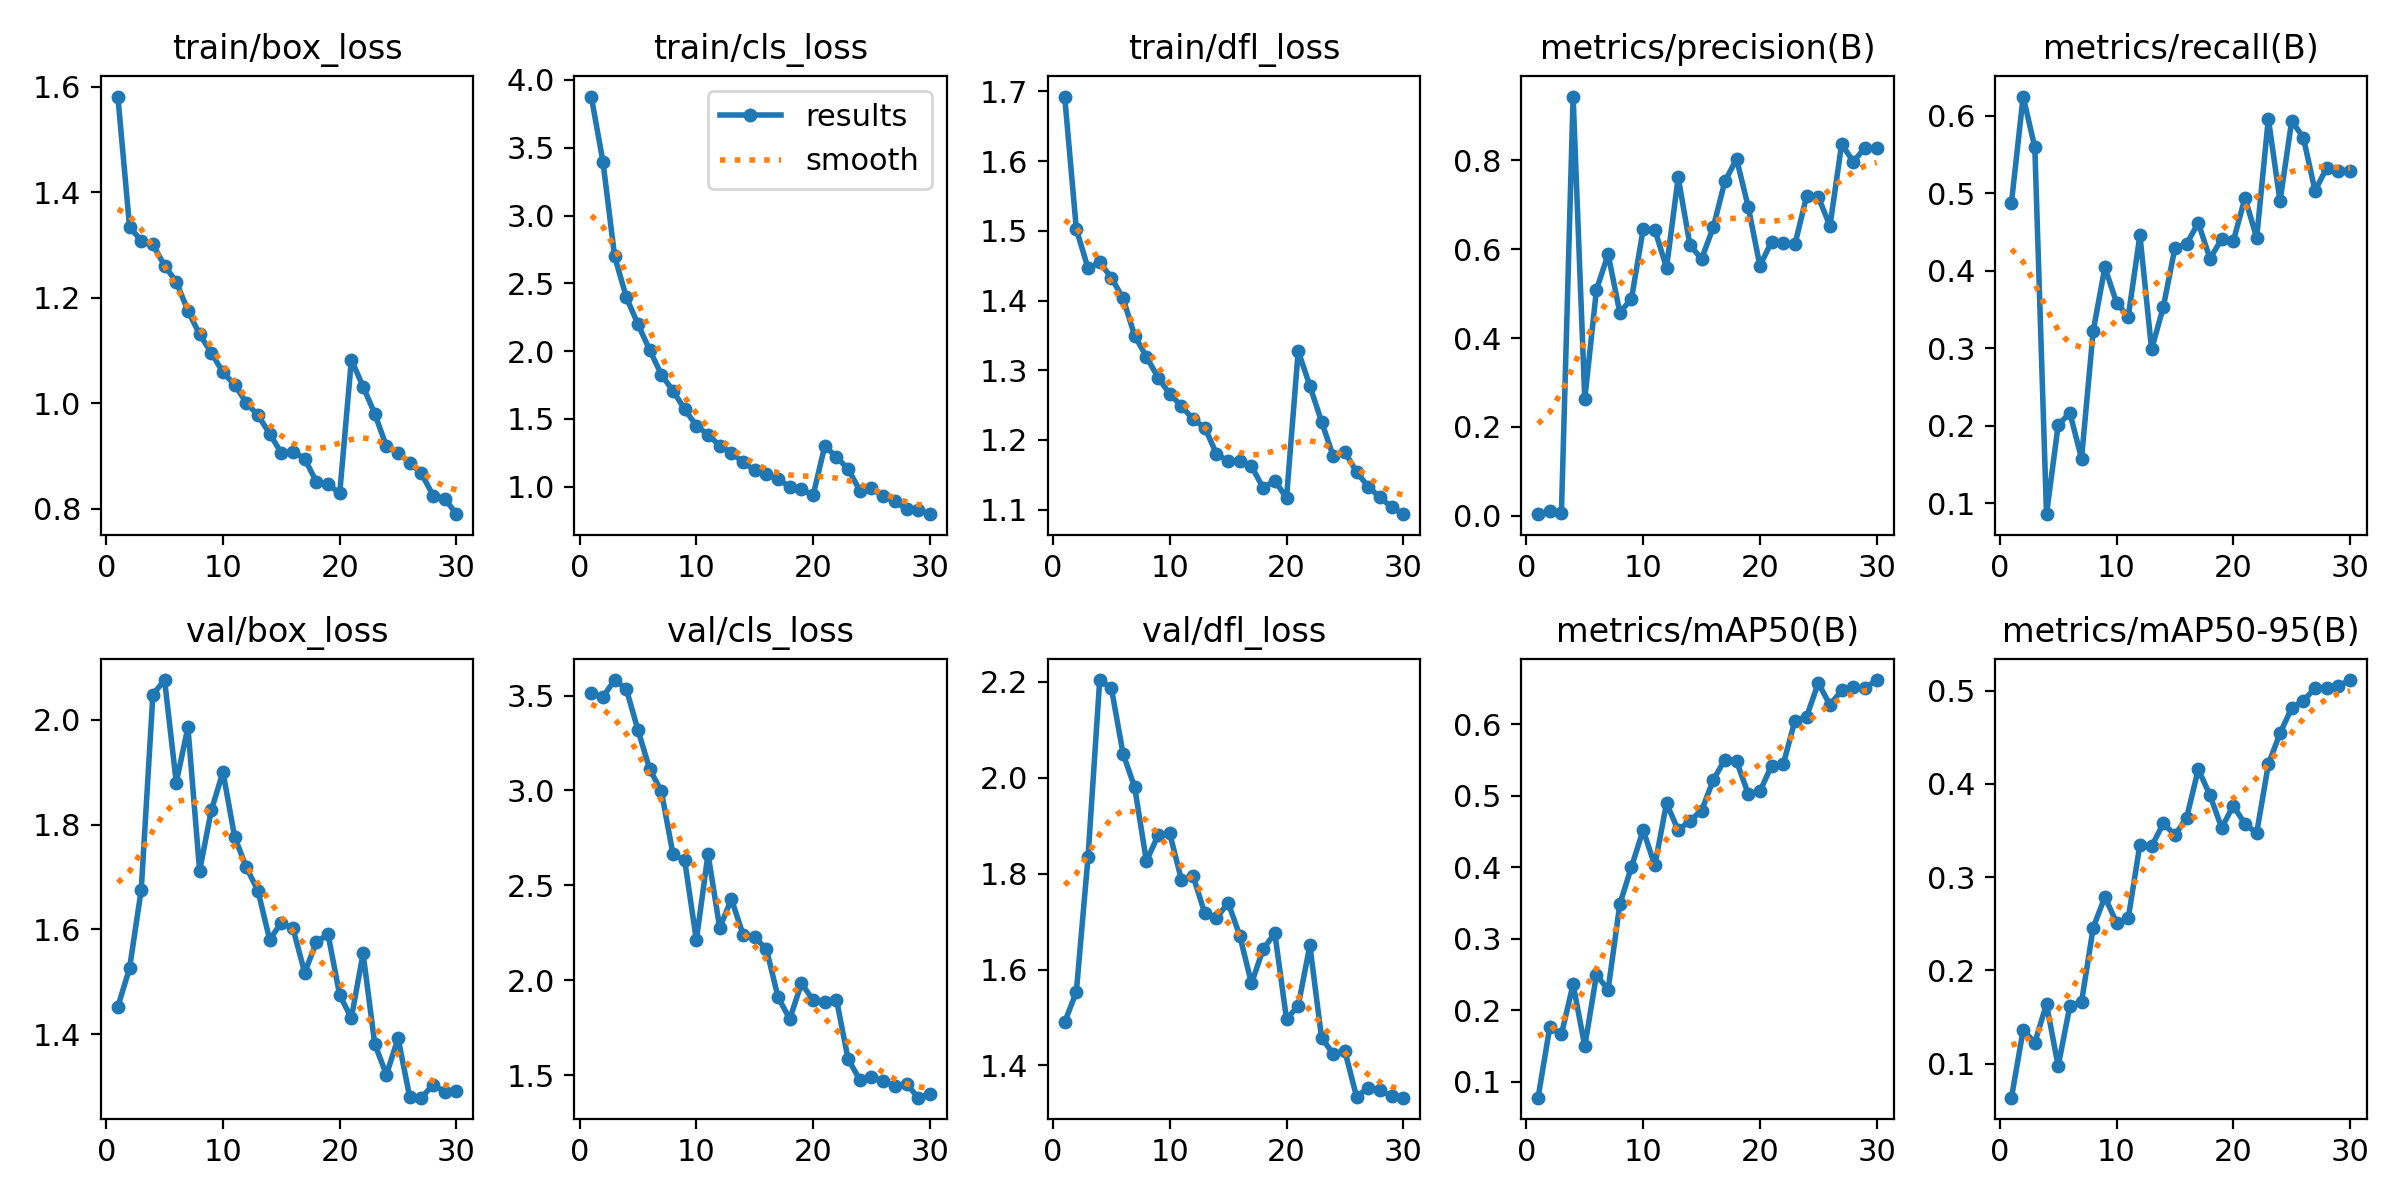


--- confusion_matrix.png ---


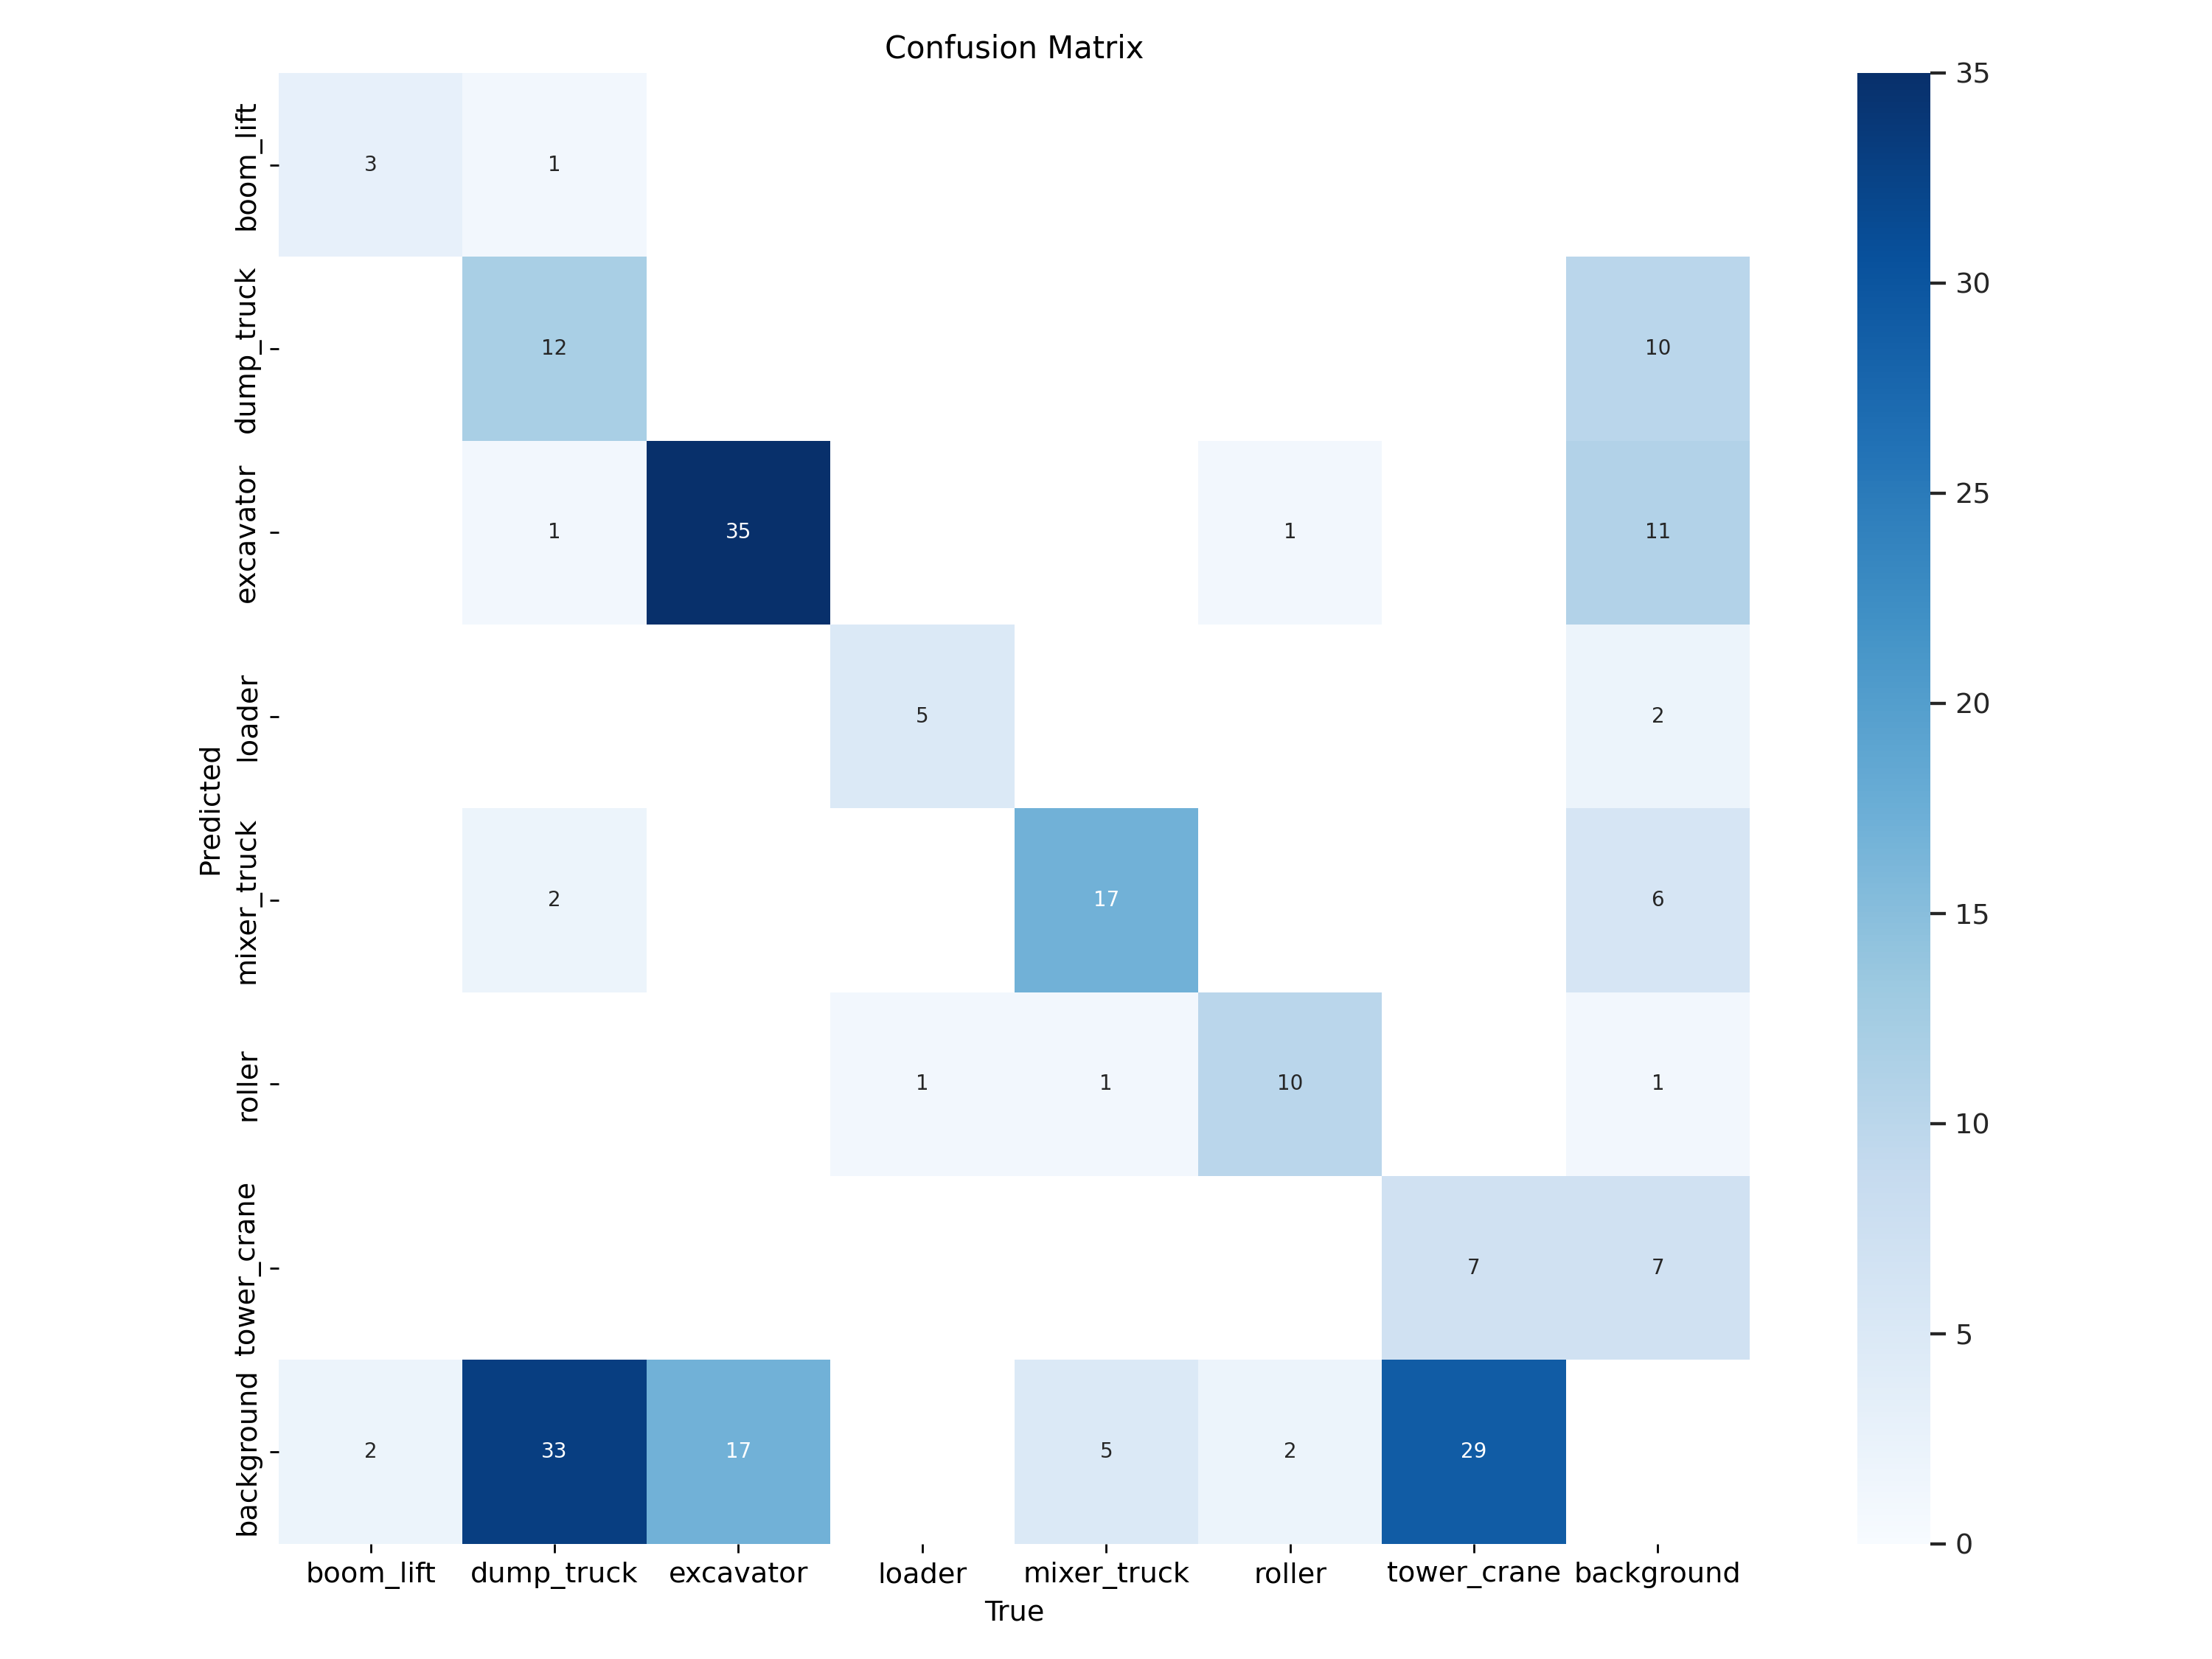


--- confusion_matrix_normalized.png ---


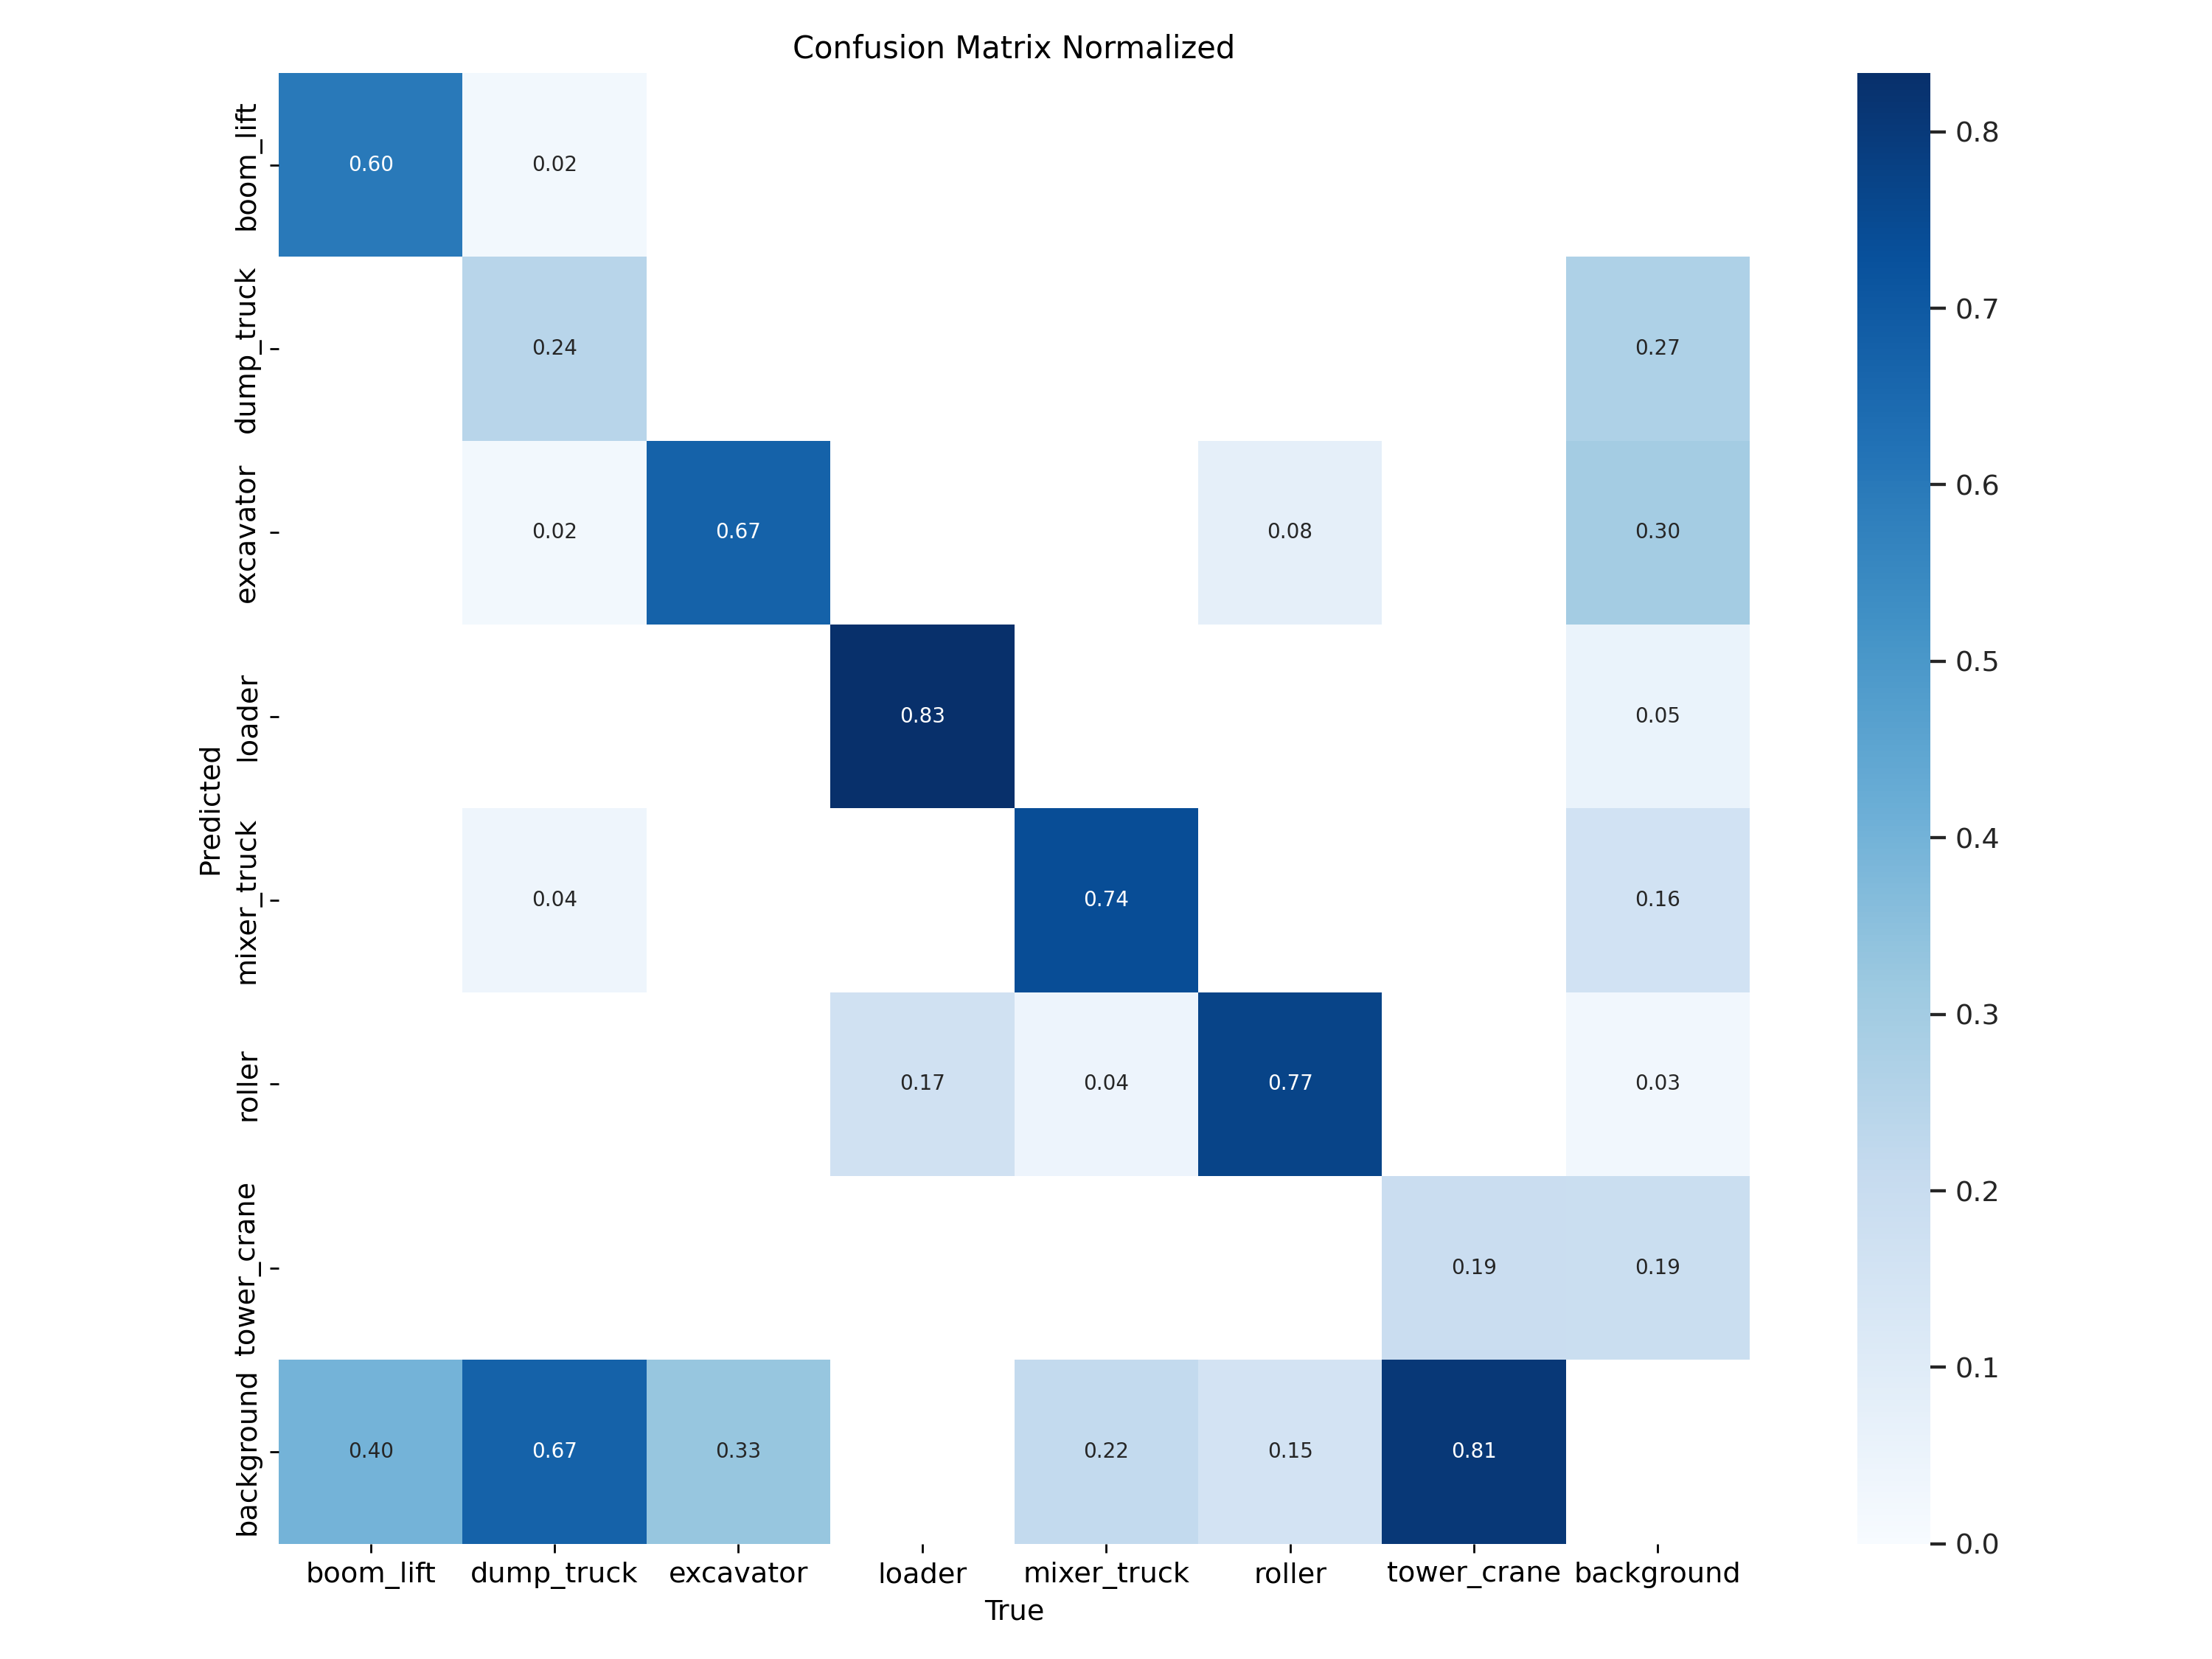


--- P_curve.png ---


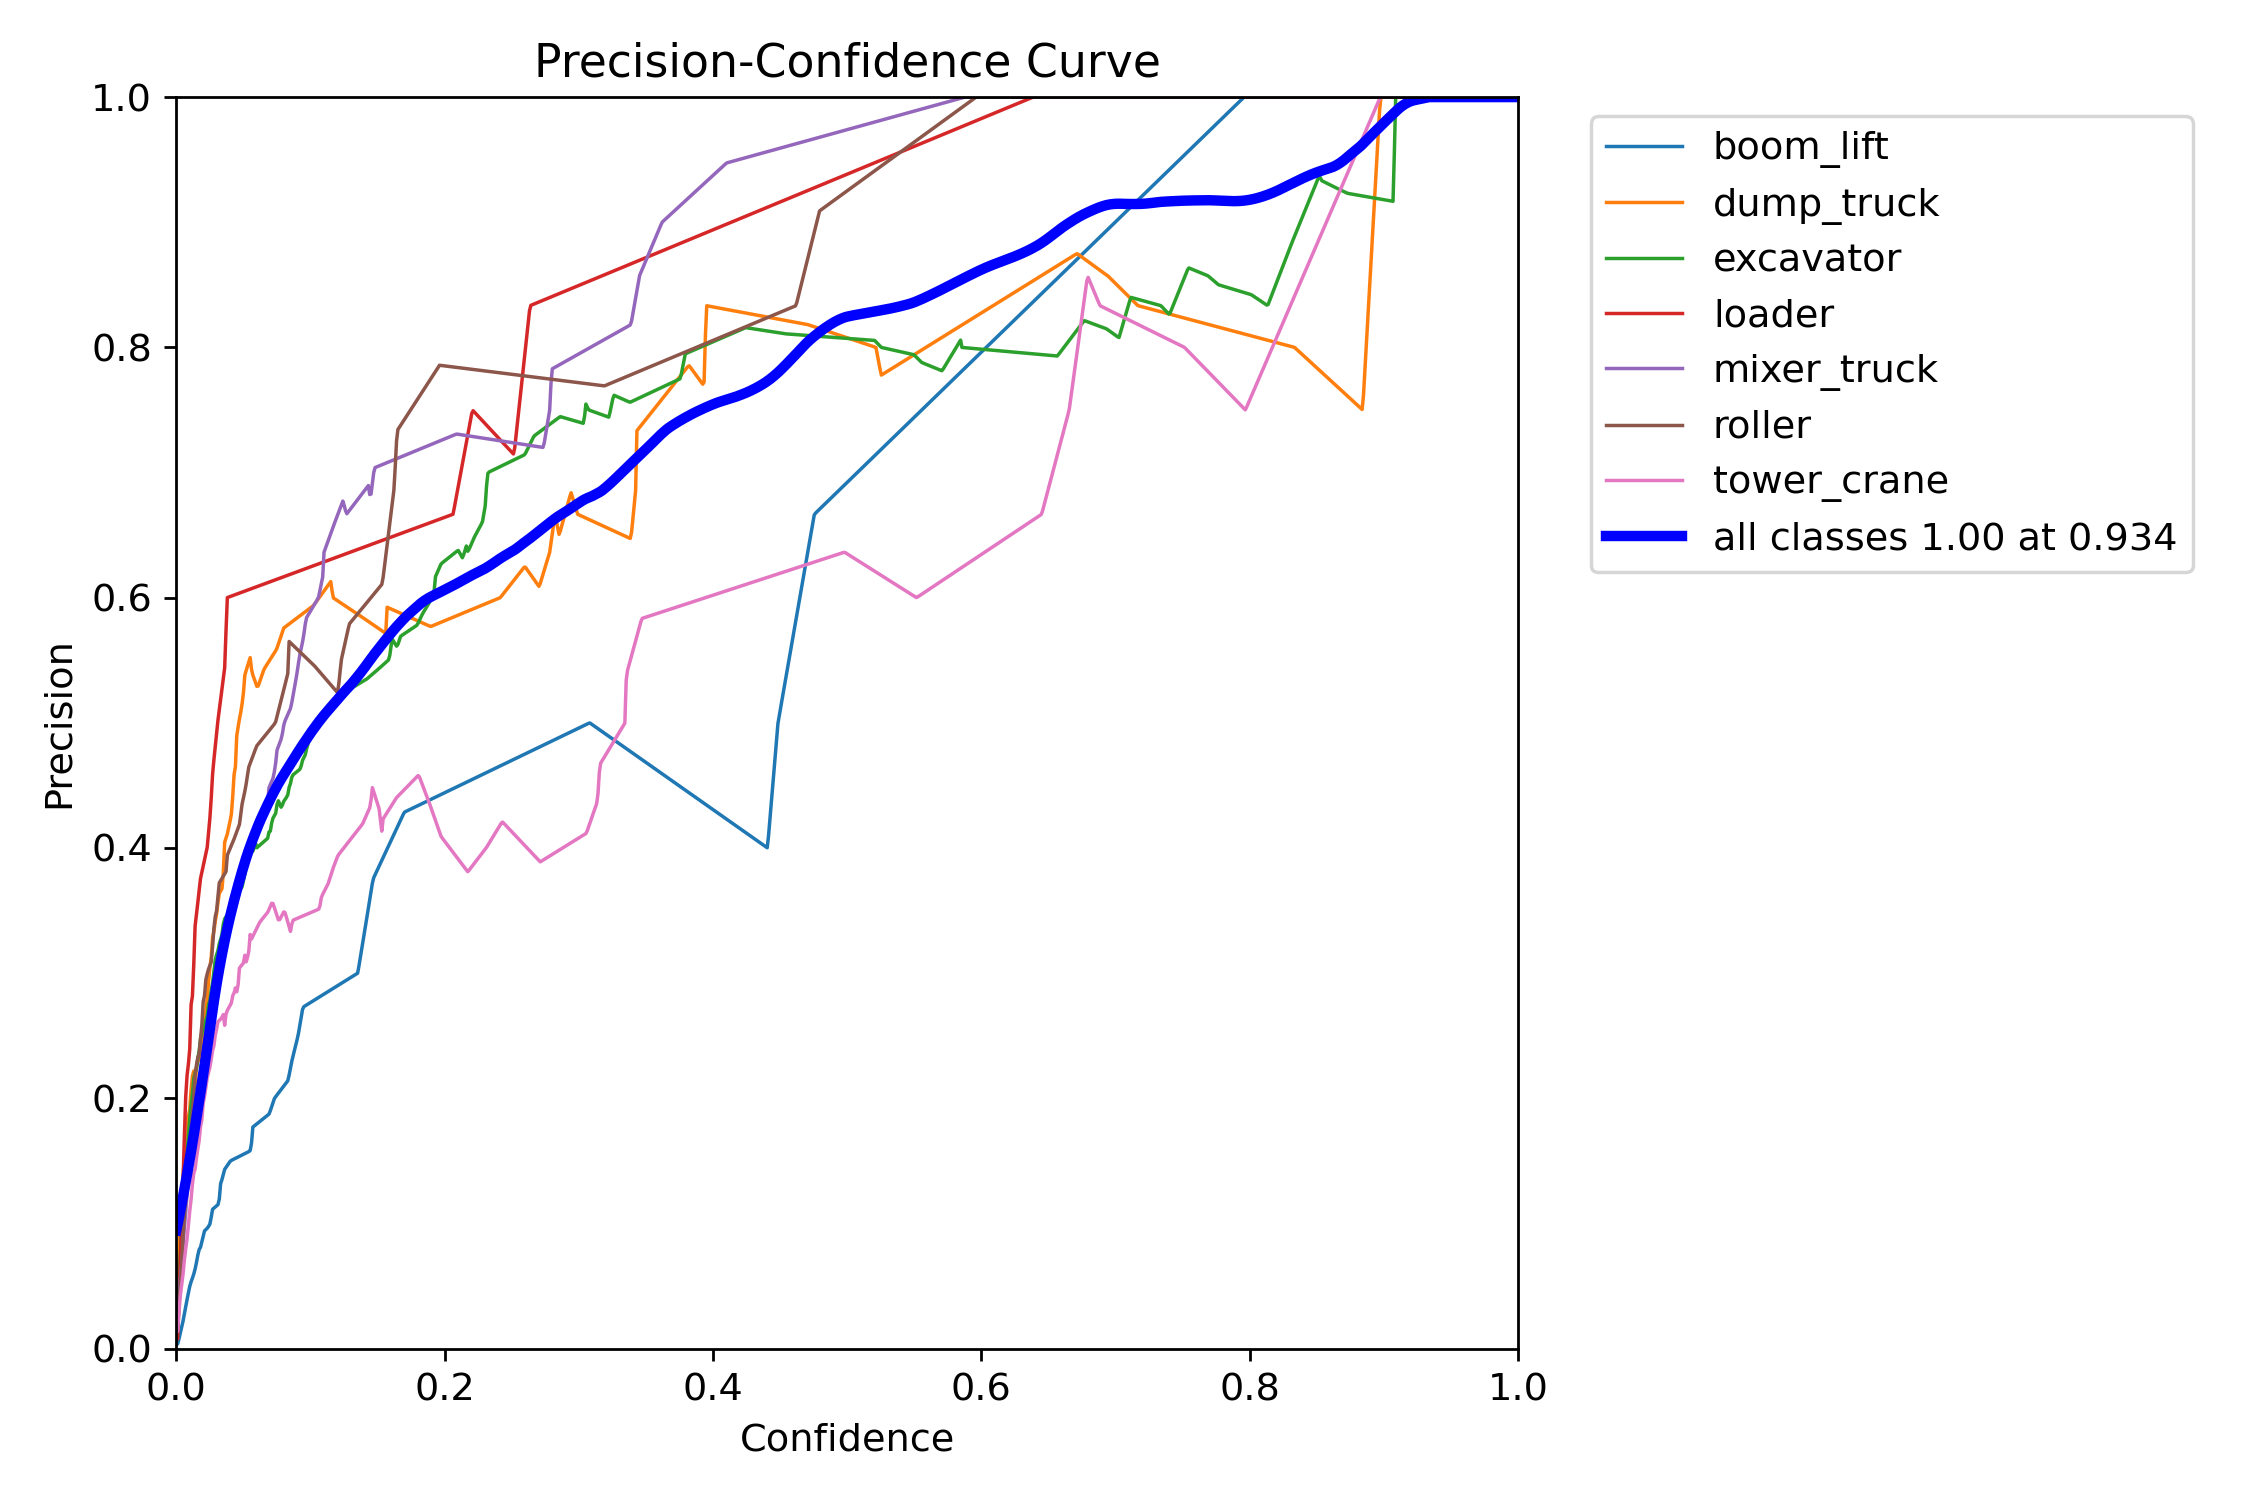


--- R_curve.png ---


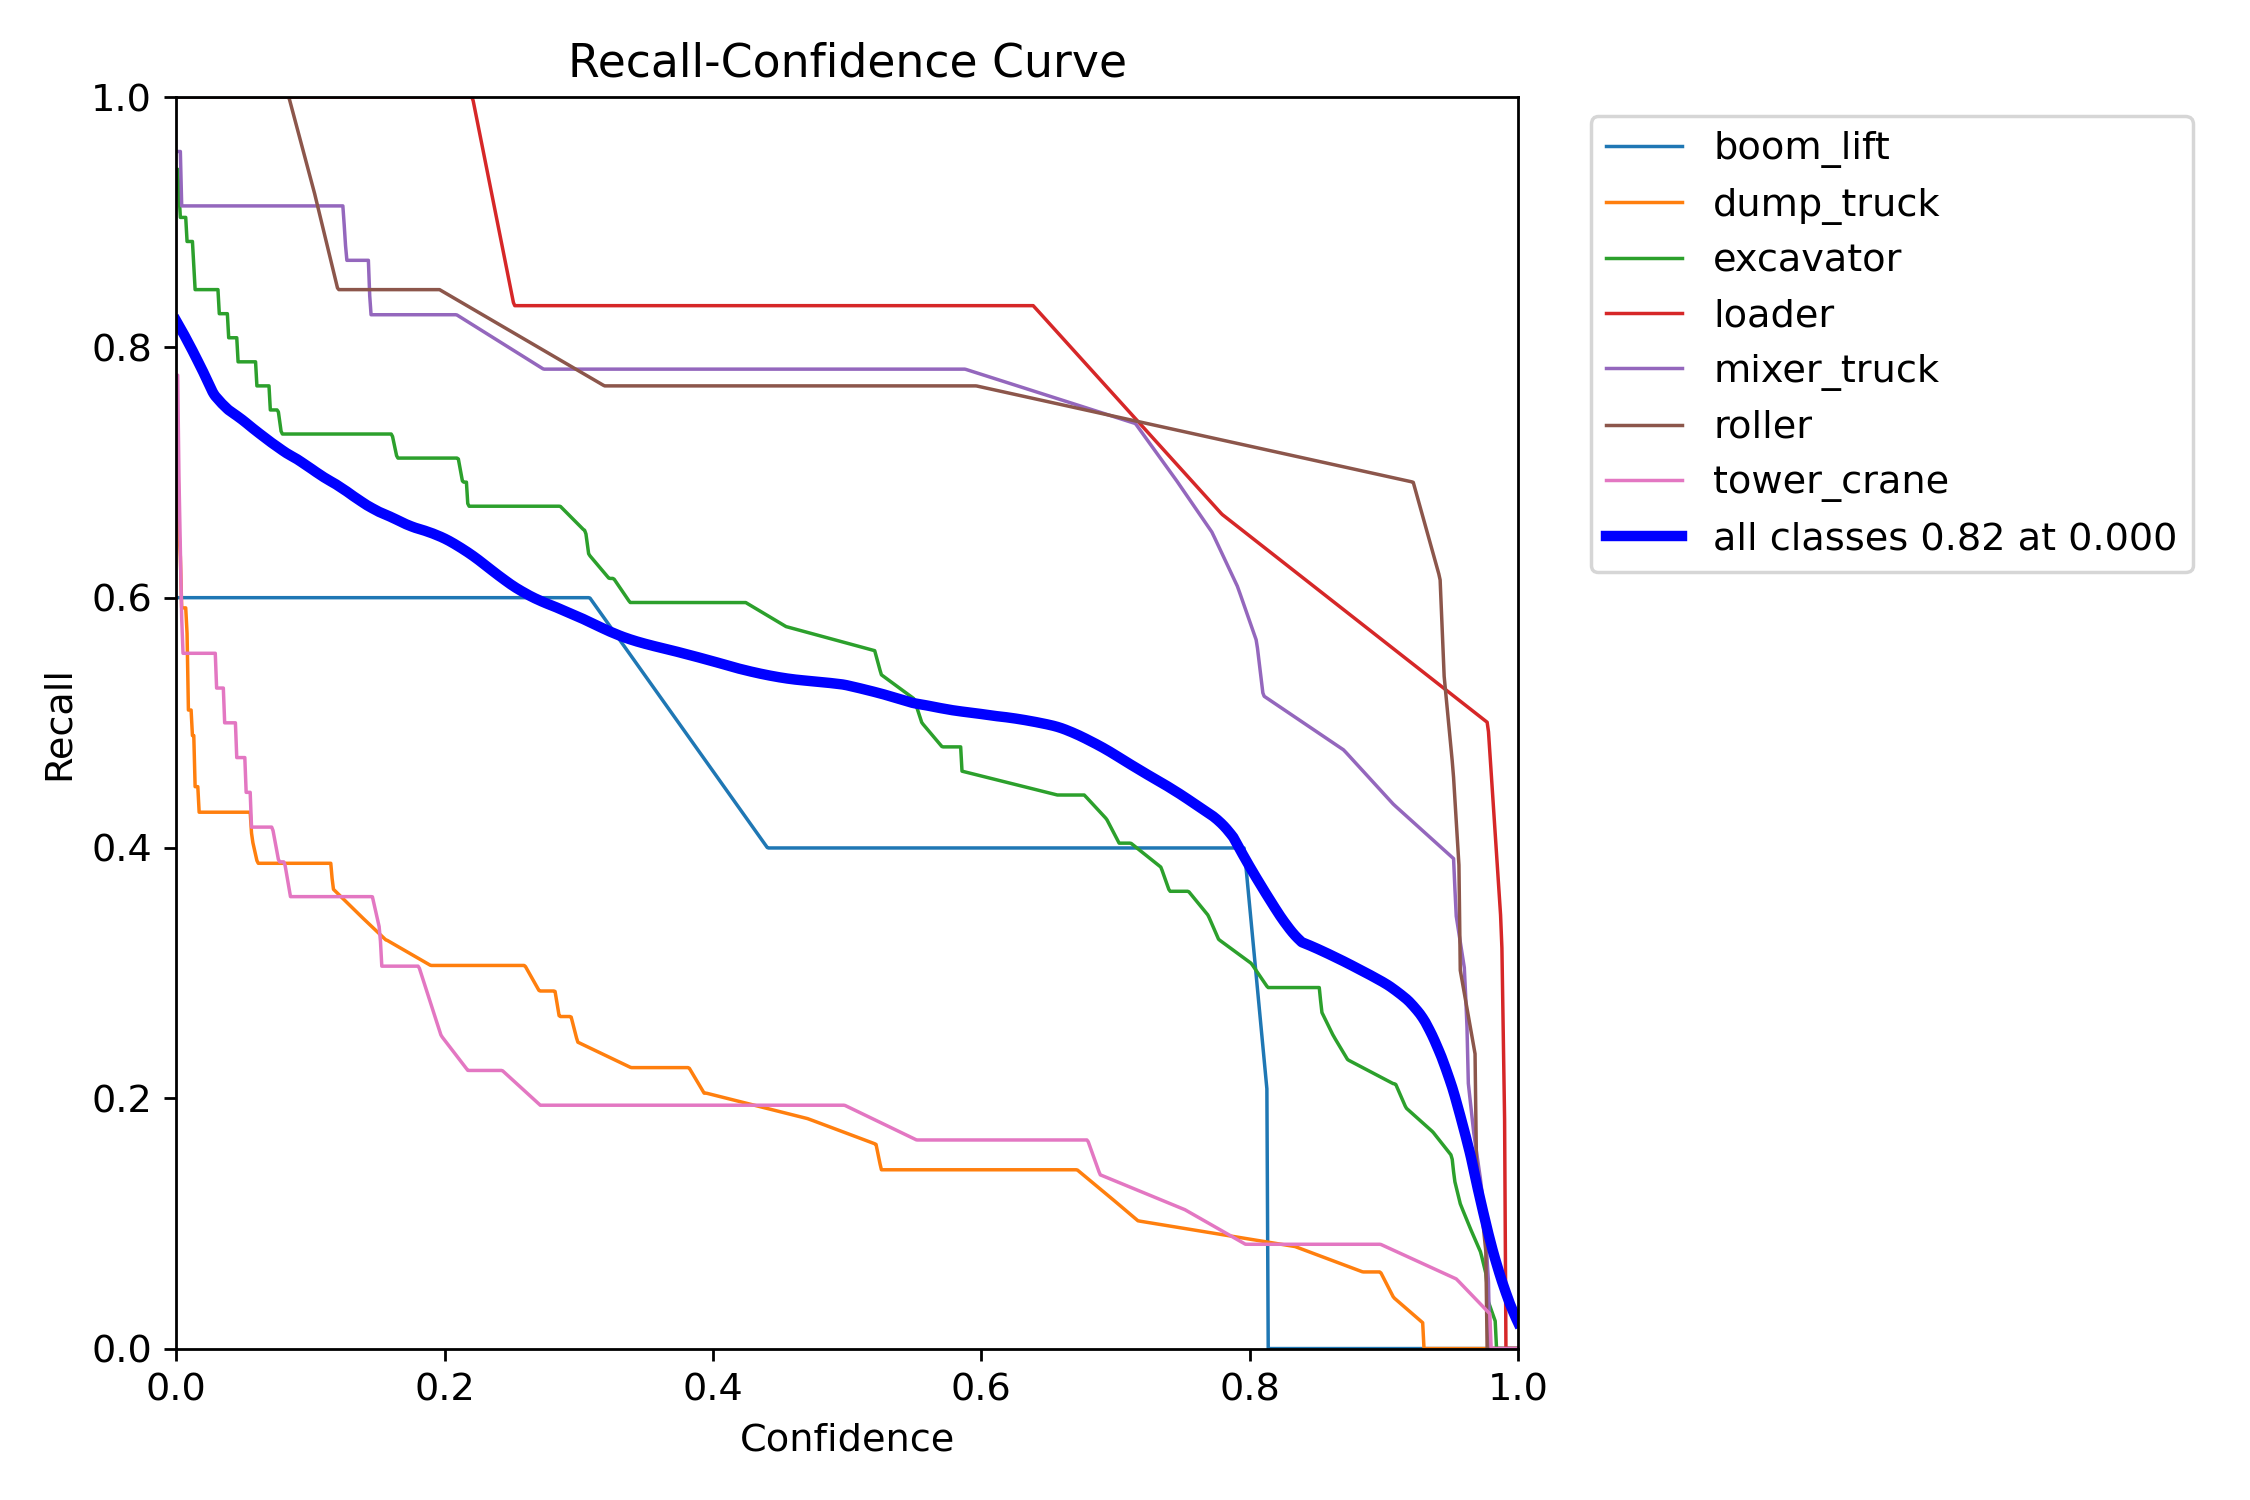


--- F1_curve.png ---


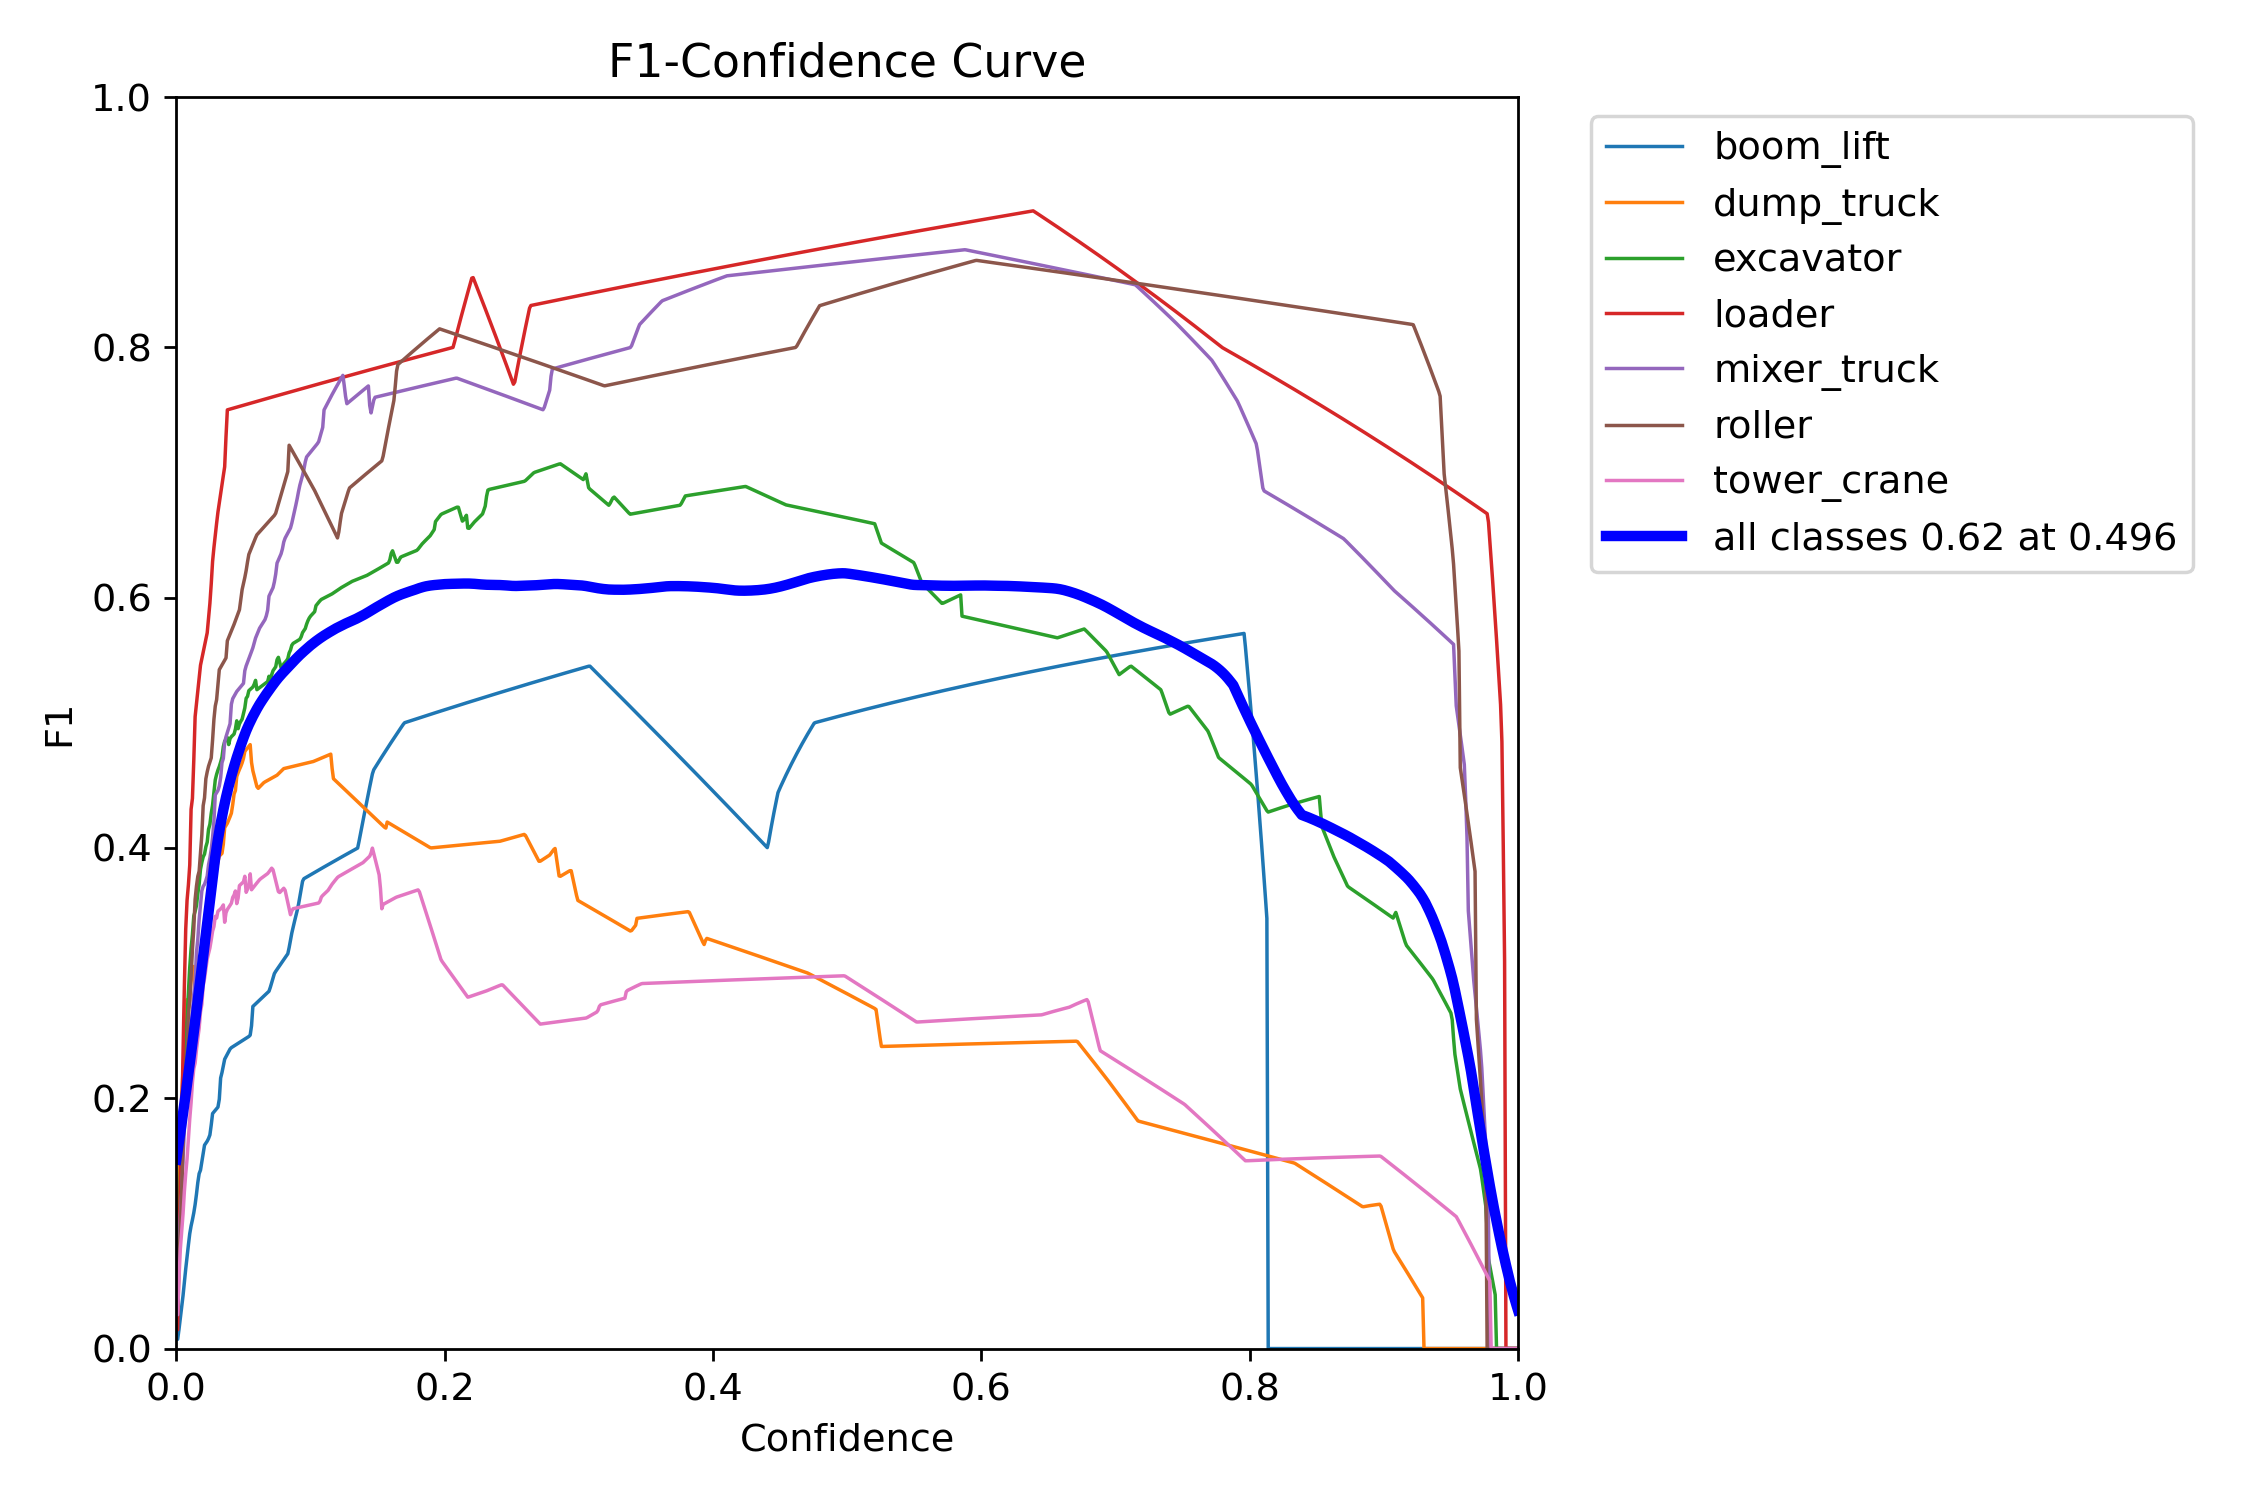


--- PR_curve.png ---


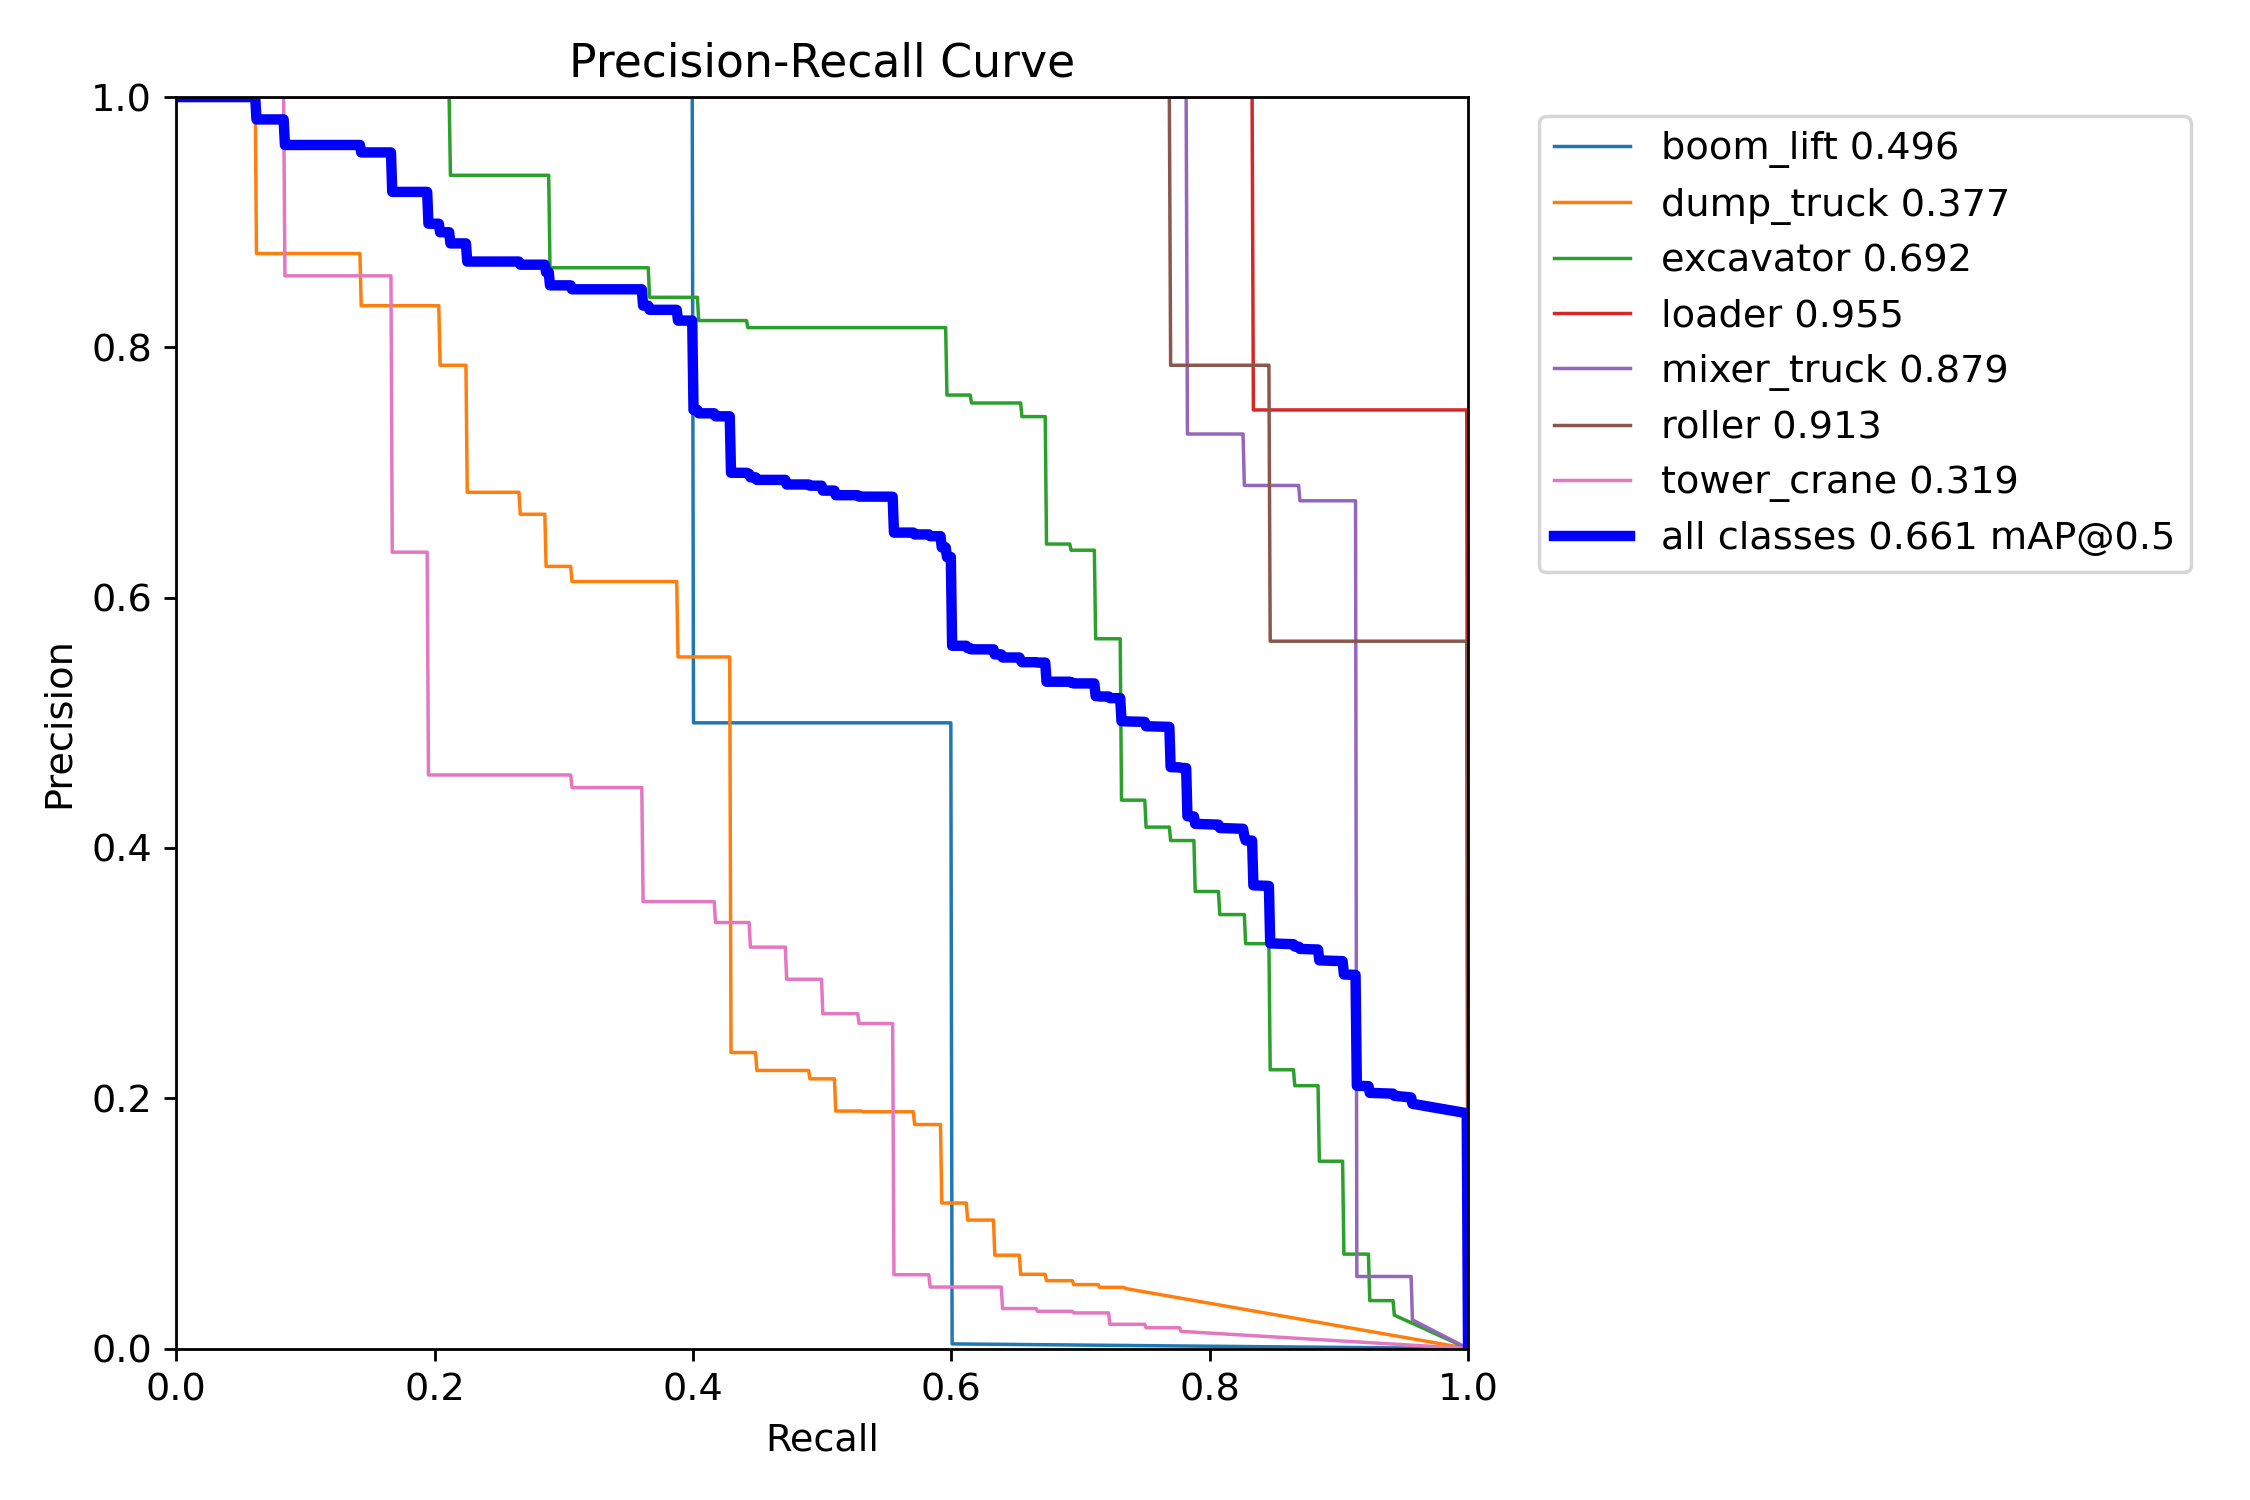



✅ Displayed 7 training plots.


In [ ]:
from IPython.display import display, Image
import os

curves_dir = '/content/runs/detect/siteai_equipment/'

plot_files = [
    'results.png',
    'confusion_matrix.png',
    'confusion_matrix_normalized.png',
    'P_curve.png',
    'R_curve.png',
    'F1_curve.png',
    'PR_curve.png'
]

print("📊 Training Curves & Plots\n")
found = 0
for plot in plot_files:
    path = os.path.join(curves_dir, plot)
    if os.path.exists(path):
        print(f"--- {plot} ---")
        display(Image(filename=path, width=700))
        print()
        found += 1

print(f"\n✅ Displayed {found} training plots.")

# Validation Predictions (10 examples)

Running predictions on 10 validation images...


0: 640x640 5 dump_trucks, 4 excavators, 6.5ms
1: 640x640 3 excavators, 6.5ms
2: 640x640 1 excavator, 6.5ms
3: 640x640 1 dump_truck, 3 excavators, 1 mixer_truck, 6.5ms
4: 640x640 1 boom_lift, 7 dump_trucks, 7 excavators, 6.5ms
5: 640x640 2 excavators, 6.5ms
6: 640x640 1 excavator, 6.5ms
7: 640x640 5 excavators, 6.5ms
8: 640x640 2 dump_trucks, 2 excavators, 6.5ms
9: 640x640 2 dump_trucks, 3 excavators, 1 roller, 6.5ms
Speed: 3.1ms preprocess, 6.5ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/val_predictions
📸 000008_jpg.rf.1cda84c1ddb34b24de081934c0d3ab47.jpg


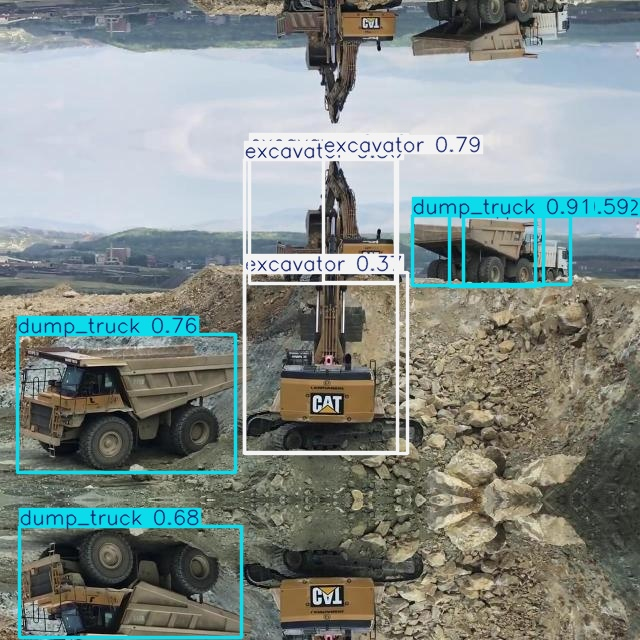


📸 000038_jpg.rf.2fbdffd98ca96a48e049a14cbfad40df.jpg


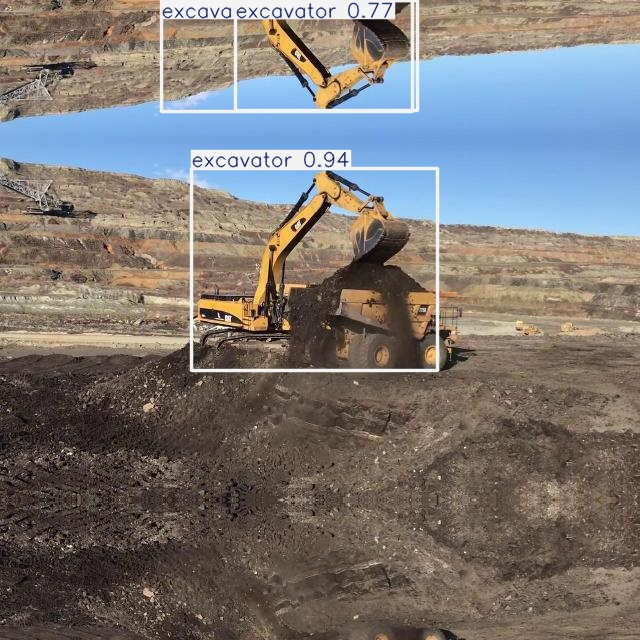


📸 000040_jpg.rf.c1647376127c917bc3a793209782c2dd.jpg


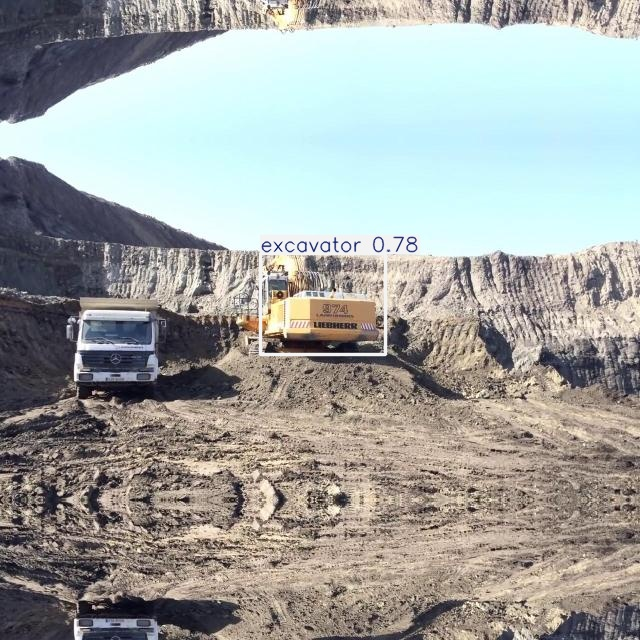


📸 000042_jpg.rf.390297a0e5c95bffa998deecfbadee17.jpg


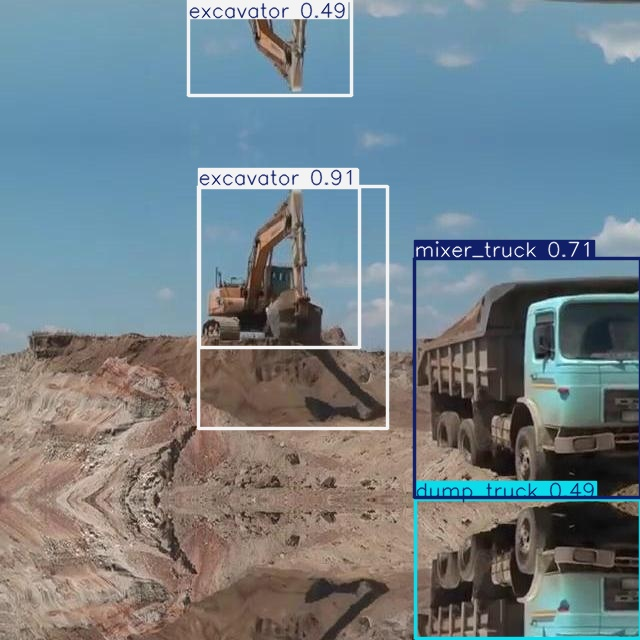


📸 000048_jpg.rf.30a0cf0037b29a83233ee94170897a51.jpg


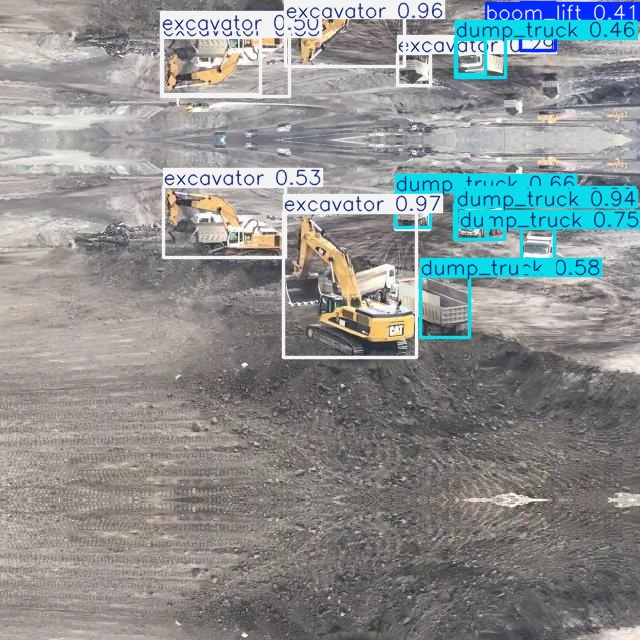


📸 000051_jpg.rf.da2afef4851f0e3f50af386d930ed089.jpg


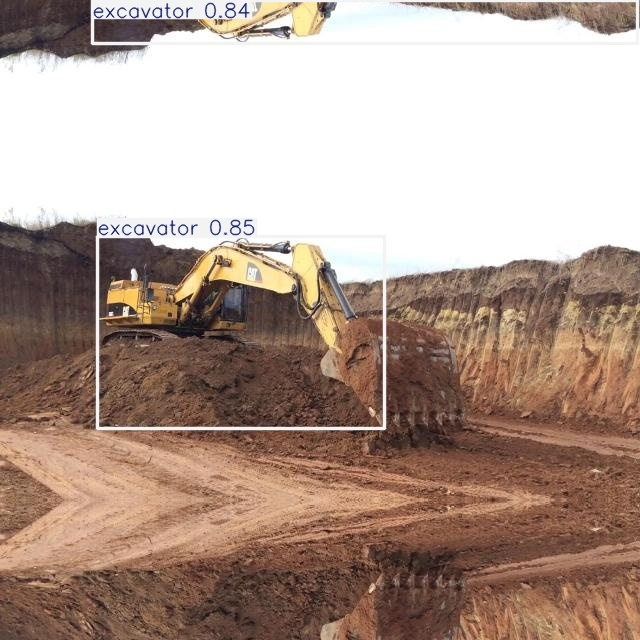


📸 000052_jpg.rf.4d5cdc6274c99e02c602ca6b73a71859.jpg


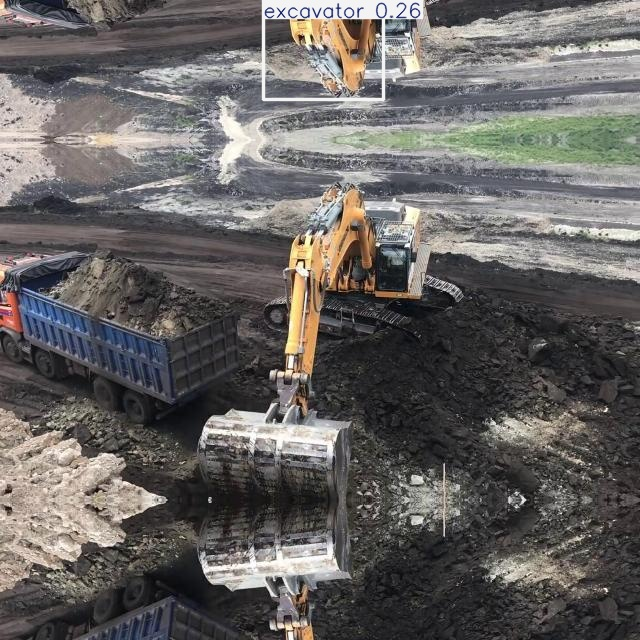


📸 000064_jpg.rf.271651cdc3fc83db5262642b562598a4.jpg


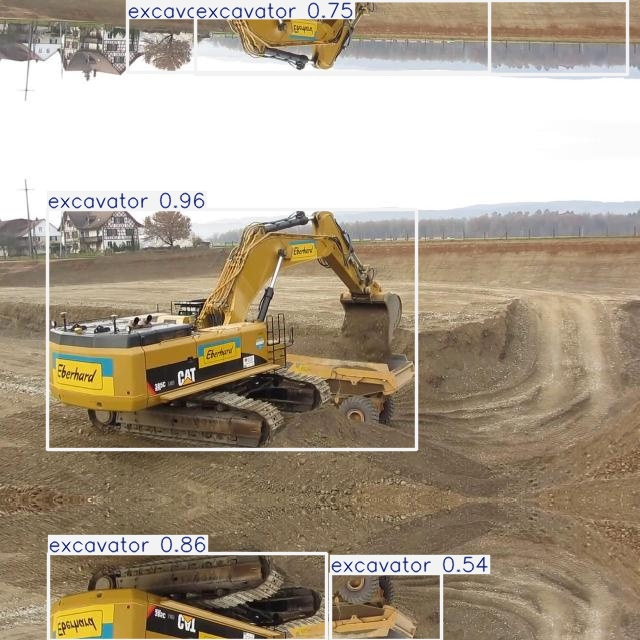


📸 000080_jpg.rf.032bb068853769c4307aaafe6a142e4e.jpg


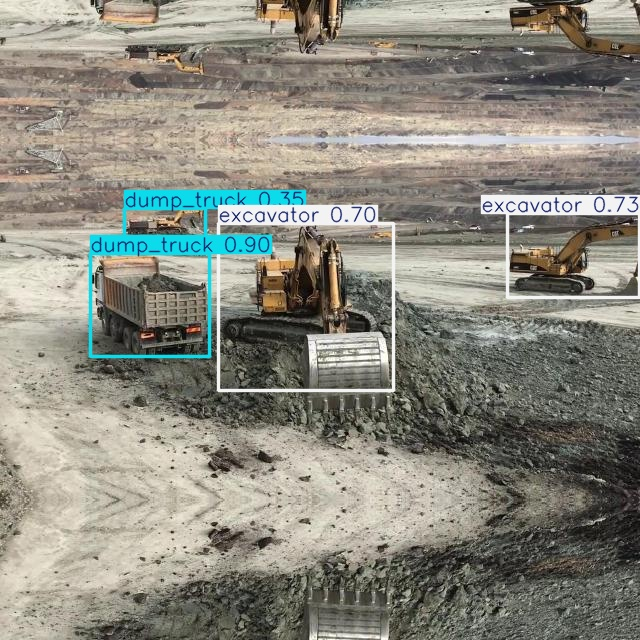


📸 000084_jpg.rf.f2495ec8027845b624538b566e30ec3e.jpg


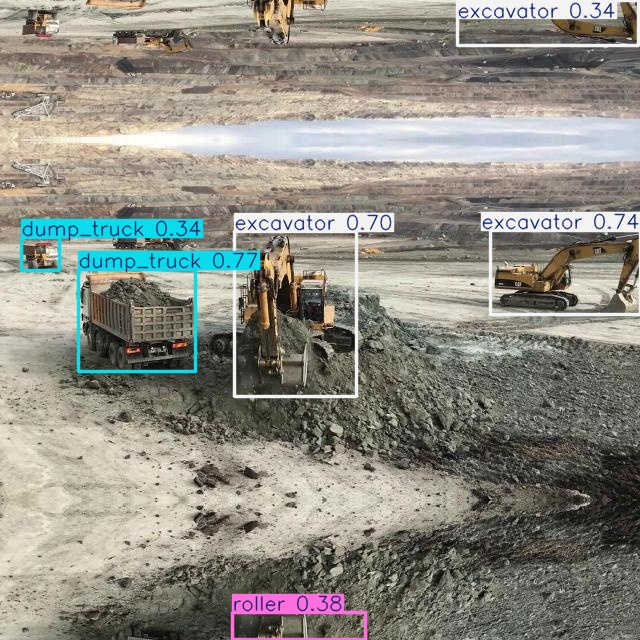



✅ Displayed 10 validation predictions.


In [ ]:
import glob
from IPython.display import display, Image

# Get 10 validation images
val_images = sorted(glob.glob('/content/dataset/valid/images/*'))[:10]
print(f"Running predictions on {len(val_images)} validation images...\n")

# Run inference
results = model.predict(
    source=val_images,
    save=True,
    conf=0.25,
    name='val_predictions'
)

# Display predictions
pred_dir = '/content/runs/detect/val_predictions/'
pred_images = sorted([f for f in os.listdir(pred_dir) if f.endswith(('.jpg', '.png'))])

for img_name in pred_images[:10]:
    img_path = os.path.join(pred_dir, img_name)
    print(f"📸 {img_name}")
    display(Image(filename=img_path, width=500))
    print()

print(f"\n✅ Displayed {len(pred_images[:10])} validation predictions.")

#  New Image Predictions (automated, no manual upload)

📁 Upload 5 new construction equipment images:
   (images the model has NEVER seen during training)



Saving construction-cranes.webp to construction-cranes.webp
Saving discover-the-benefits-of-a-concrete-mixer-truck-featured-image.jpg to discover-the-benefits-of-a-concrete-mixer-truck-featured-image.jpg
Saving ex7.jpg to ex7.jpg
Saving images.jpeg to images.jpeg
Saving road-roller.webp to road-roller.webp

image 1/5 /content/new_test_images/construction-cranes.webp: 448x640 1 tower_crane, 46.3ms
image 2/5 /content/new_test_images/discover-the-benefits-of-a-concrete-mixer-truck-featured-image.jpg: 448x640 1 excavator, 6.8ms
image 3/5 /content/new_test_images/ex7.jpg: 448x640 3 excavators, 6.1ms
image 4/5 /content/new_test_images/images.jpeg: 480x640 (no detections), 41.9ms
image 5/5 /content/new_test_images/road-roller.webp: 512x640 1 roller, 42.3ms
Speed: 3.0ms preprocess, 28.7ms inference, 1.2ms postprocess per image at shape (1, 3, 512, 640)
Results saved to runs/detect/new_predictions
📸 discover-the-benefits-of-a-concrete-mixer-truck-featured-image.jpg


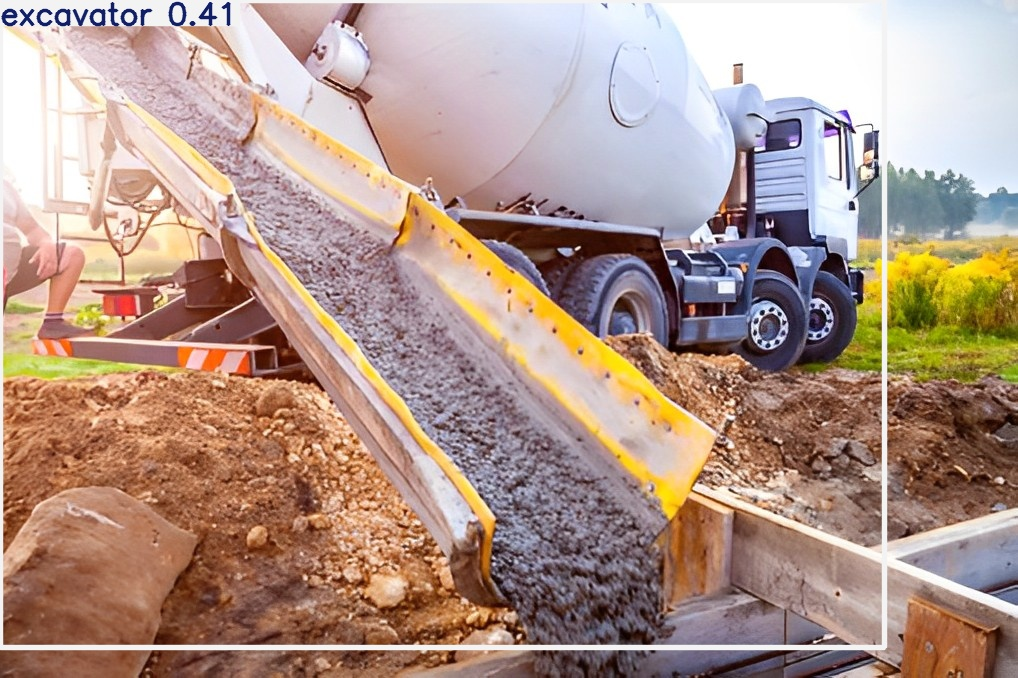


📸 ex7.jpg


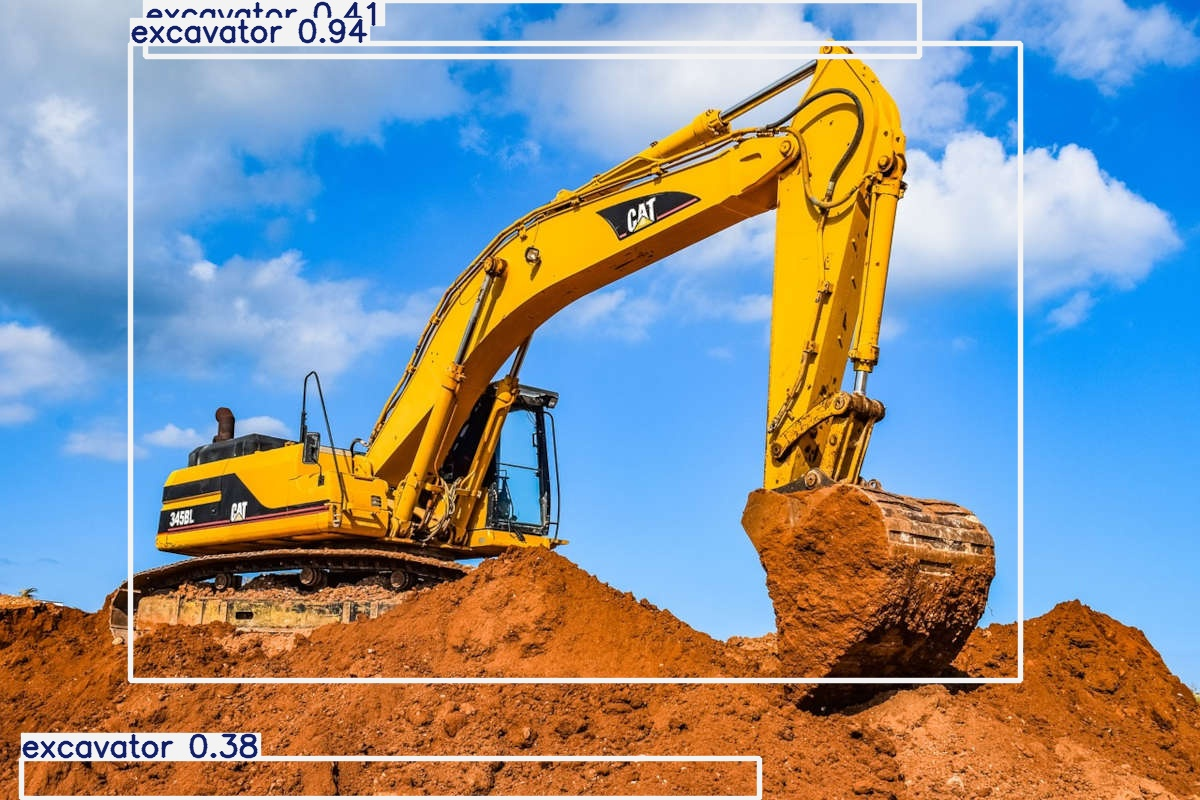



✅ Displayed 2 new image predictions.


In [ ]:
# ============================================================
# Download new test images from GitHub repo (no manual upload)
# ============================================================
import urllib.request
import os

new_img_dir = '/content/new_test_images/'
os.makedirs(new_img_dir, exist_ok=True)

# Base URL for raw files in your repo
base_url = "https://raw.githubusercontent.com/Vagiadim/SiteAI-equipment-tracker-/main/results/evidence/new_test_images/"

# List your 5 image filenames here
new_images = [
    "excavator_test.jpg",
    "tower_crane_test.jpg",
    "mixer_truck_test.jpg",
    "roller_test.jpg",
    "boom_lift_test.jpg"
]

print("📥 Downloading new test images from GitHub...\n")
for img_name in new_images:
    url = base_url + img_name
    save_path = os.path.join(new_img_dir, img_name)
    urllib.request.urlretrieve(url, save_path)
    print(f"  ✅ {img_name}")

# Run inference
results = model.predict(
    source=new_img_dir,
    save=True,
    conf=0.25,
    name='new_predictions'
)

# Display predictions
pred_dir = '/content/runs/detect/new_predictions/'
pred_images = sorted([f for f in os.listdir(pred_dir) if f.endswith(('.jpg', '.png'))])

for img_name in pred_images:
    img_path = os.path.join(pred_dir, img_name)
    print(f"📸 {img_name}")
    display(Image(filename=img_path, width=500))
    print()

print(f"\n✅ {len(pred_images)} new image predictions complete.")

# Download Weights (also automated)

In [ ]:
# ============================================================
# Load weights — from training run OR download from GitHub
# ============================================================
import os

best_weights = '/content/runs/detect/siteai_equipment/weights/best.pt'

# If weights don't exist (skipped training), download from GitHub
if not os.path.exists(best_weights):
    print("📥 Downloading pre-trained weights from GitHub Release...")
    os.makedirs(os.path.dirname(best_weights), exist_ok=True)
    !wget -q -O {best_weights} "https://github.com/Vagiadim/SiteAI-equipment-tracker-/releases/download/v1.0/best.pt"
    print("✅ Weights downloaded.")

model = YOLO(best_weights)

📦 Downloading best.pt (5.4 MB)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Weights downloaded. Upload this to your GitHub repo releases.


# Reproducibility Summary

In [ ]:
import datetime
import torch
import ultralytics

print("="*50)
print("    REPRODUCIBILITY SUMMARY")
print("="*50)
print(f"  Date/Time:         {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Ultralytics ver:   {ultralytics.__version__}")
print(f"  PyTorch ver:       {torch.__version__}")
print(f"  GPU:               {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"  Model:             YOLOv8n")
print(f"  Dataset:           SiteAI-equipment-tracker v9 (Team7_Dataset_V1)")
print(f"  Split:             80/20 (train/val)")
print(f"  Epochs:            30")
print(f"  Image size:        640")
print(f"  Batch:             auto")
print(f"  Patience:          10 (early stopping)")
print("="*50)
print("\nCopy the above into your README reproducibility checklist.")

    REPRODUCIBILITY SUMMARY
  Date/Time:         2026-02-24 21:24:50
  Ultralytics ver:   8.3.0
  PyTorch ver:       2.10.0+cu128
  GPU:               Tesla T4
  Model:             YOLOv8n
  Dataset:           SiteAI-equipment-tracker v9 (Team7_Dataset_V1)
  Split:             80/20 (train/val)
  Epochs:            30
  Image size:        640
  Batch:             auto
  Patience:          10 (early stopping)

Copy the above into your README reproducibility checklist.
